# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
df.info()

(541909, 8)
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), f

## A.2. Missing values & Duplicate data

In [3]:
print(df.isnull().sum())
print("Số dòng trùng lặp:", df.duplicated().sum())


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Số dòng trùng lặp: 5268


## A.3. Invalid values

In [4]:
print(df.describe())

print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())
print("CustomerID null:", df['CustomerID'].isnull().sum())
print("Số quốc gia:", df['Country'].nunique())
print(df['Country'].unique())

            Quantity                 InvoiceDate      UnitPrice     CustomerID
count  541909.000000                      541909  541909.000000  406829.000000
mean        9.552250  2011-07-04 13:34:57.156386       4.611114   15287.690570
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12346.000000
25%         1.000000         2011-03-28 11:34:00       1.250000   13953.000000
50%         3.000000         2011-07-19 17:17:00       2.080000   15152.000000
75%        10.000000         2011-10-19 11:27:00       4.130000   16791.000000
max     80995.000000         2011-12-09 12:50:00   38970.000000   18287.000000
std       218.081158                         NaN      96.759853    1713.600303
Quantity <= 0: 10624
UnitPrice <= 0: 2517
CustomerID null: 135080
Số quốc gia: 38
<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland'

## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [5]:
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']
print("Số dòng trước khi lọc:", len(df), "| sau khi lọc:", len(df_clean))
df_clean.head()


Số dòng trước khi lọc: 541909 | sau khi lọc: 530104


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    print(col)
    print(" Mean:", df_clean[col].mean())
    print(" Median:", df_clean[col].median())
    print(" Mode:", df_clean[col].mode()[0])


Quantity
 Mean: 10.542037034242338
 Median: 3.0
 Mode: 1
UnitPrice
 Mean: 3.9076252471213193
 Median: 2.08
 Mode: 1.25
Sales
 Mean: 20.121871451639677
 Median: 9.9
 Mode: 15.0


## Group 2 — Dispersion

In [7]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    print(col)
    print(" Std:", df_clean[col].std())
    print(" Variance:", df_clean[col].var())
    print(" Range:", df_clean[col].max() - df_clean[col].min())
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    print(" IQR:", q3 - q1)

Quantity
 Std: 155.52412351063626
 Variance: 24187.752993751637
 Range: 80994
 IQR: 9.0
UnitPrice
 Std: 35.915681104255434
 Variance: 1289.936149182571
 Range: 13541.329
 IQR: 2.88
Sales
 Std: 270.35674321840673
 Variance: 73092.76860366353
 Range: 168469.59900000002
 IQR: 13.950000000000003


## Group 3 — Location and Shape

In [8]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    print(col)
    print(" Quartiles:", df_clean[col].quantile([0.25, 0.5, 0.75]).tolist())
    print(" Skewness:", df_clean[col].skew())
    print(" Kurtosis:", df_clean[col].kurt())


Quantity
 Quartiles: [1.0, 3.0, 10.0]
 Skewness: 471.72771633134437
 Kurtosis: 236462.34282634684
UnitPrice
 Quartiles: [1.25, 2.08, 4.13]
 Skewness: 206.08755495006466
 Kurtosis: 62483.1427151048
Sales
 Quartiles: [3.75, 9.9, 17.700000000000003]
 Skewness: 506.7060119422723
 Kurtosis: 297651.6610458157


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [9]:
country_sales = df_clean.groupby('Country')['Sales'].sum().sort_values(ascending=False)
top_country = country_sales.index[0]
top_pct = country_sales.iloc[0] / country_sales.sum() * 100
print(country_sales.head(10))
print(f"\n{top_country} chiếm {top_pct:.2f}% tổng doanh thu")


Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Sales, dtype: float64

United Kingdom chiếm 84.61% tổng doanh thu


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [10]:
product_sales = df_clean.groupby('Description')['Sales'].sum().sort_values(ascending=False)
print(product_sales.head(10))


Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Sales, dtype: float64


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

Month
2010-12     823746.140
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638792.680
Freq: M, Name: Sales, dtype: float64


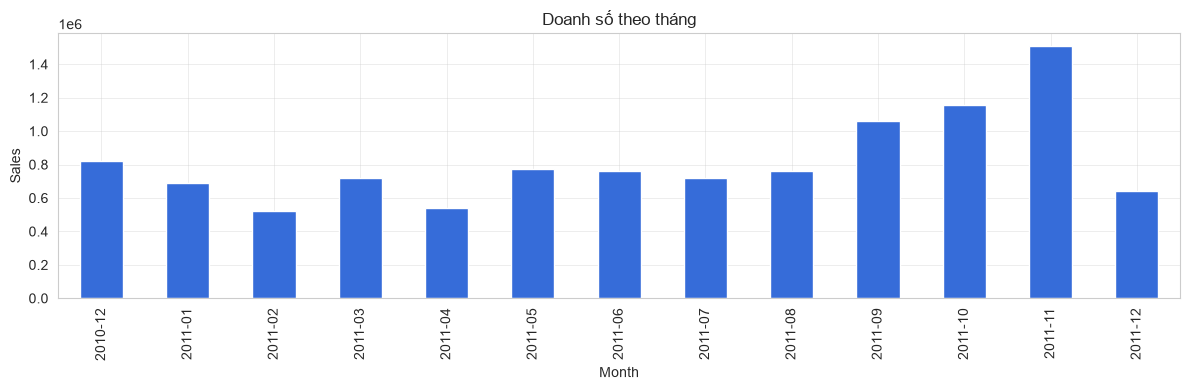

In [11]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_sales = df_clean.groupby('Month')['Sales'].sum()
print(monthly_sales)

monthly_sales.plot(kind='bar', figsize=(12, 4))
plt.title('Doanh số theo tháng')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [12]:
order_value = df_clean.groupby(['Country', 'InvoiceNo'])['Sales'].sum().reset_index()
aov_by_country = order_value.groupby('Country')['Sales'].mean().sort_values(ascending=False)
print(aov_by_country.head(10))


Country
Singapore      3039.898571
Netherlands    3036.663191
Australia      2430.198421
Japan          1969.282632
Lebanon        1693.880000
Hong Kong      1426.527273
Brazil         1143.600000
Sweden         1066.064722
Switzerland    1057.220370
Denmark        1053.074444
Name: Sales, dtype: float64


## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [13]:
df['is_return'] = df['Quantity'] < 0
return_rate = df.groupby('Country')['is_return'].mean().sort_values(ascending=False) * 100
print(return_rate.head(10))


Country
USA               38.487973
Czech Republic    16.666667
Malta             11.811024
Japan             10.335196
Saudi Arabia      10.000000
Australia          5.877681
Italy              5.603985
Bahrain            5.263158
Germany            4.770932
EIRE               3.684724
Name: is_return, dtype: float64


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Dữ liệu ban đầu có 541,909 dòng nhưng khá "bẩn": 135,080 dòng thiếu CustomerID (khoảng 25%), 1,454 dòng thiếu Description, 5,268 dòng trùng lặp, và đặc biệt có tới 10,624 dòng Quantity ≤ 0 cùng 2,517 dòng UnitPrice ≤ 0 — sau khi lọc bỏ các giao dịch không hợp lệ này, dữ liệu còn lại 530,104 dòng để phân tích doanh thu thực. Về mặt địa lý, United Kingdom gần như chi phối toàn bộ doanh thu với 84.61% tổng doanh thu, nên mọi phân tích theo quốc gia khác thực chất chỉ đang mô tả "phần đuôi" 15% còn lại — điều này cần lưu ý khi diễn giải kết quả. Doanh số có tính mùa vụ khá rõ theo tháng: tăng dần từ giữa năm và đạt đỉnh vào tháng 11/2011 (hơn 1.5 triệu, gấp gần 3 lần tháng thấp nhất), phù hợp với mùa mua sắm cuối năm trước Giáng sinh, dù tháng 12/2011 giảm mạnh do dữ liệu chỉ ghi nhận đến ngày 9/12 (không phải cả tháng). Giá trị đơn hàng trung bình (AOV) cao nhất lại không rơi vào UK mà thuộc về các thị trường nhỏ hơn như Singapore (3,040) và Netherlands (3,037) — cao gấp nhiều lần mức trung bình chung, cho thấy các nước này tuy ít đơn hàng nhưng thường mua sỉ với số lượng lớn mỗi lần. Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy cũng chênh lệch rất lớn giữa các quốc gia, với USA cao vượt trội (38.49%, tức hơn 1/3 giao dịch), bỏ xa Czech Republic (16.67%) và Malta (11.81%) — đây là nhóm quốc gia đáng chú ý nếu công ty muốn tìm hiểu nguyên nhân trả hàng hoặc kiểm soát rủi ro logistics.